In [2]:
import jax
from jax import lax
import jax.numpy as jnp
import jax.profiler
import jax.scipy as jsp

import numpy as np
import matplotlib.pyplot as plt

In [39]:
def gen_wdh_image(x, y, beta, h0, sigma,
                    PA_deg, x0, fwhm,
                    gamma):
    """

    """
    R1 = 10 #At pixel scale 0.012"/pixel this is the IWA at g', about 4 lamb/D
    # Rotate to disk PA
    PA_rad = -jnp.deg2rad(PA_deg)
    x_rot =  jnp.sin(PA_rad) * x + jnp.cos(PA_rad) * y
    y_rot =  jnp.cos(PA_rad) * x - jnp.sin(PA_rad) * y

    r = jnp.sqrt((x_rot - x0)**2 + (y_rot)**2)

    # Base intensity
    power_law = (1. / r)**beta
    exp_term = jnp.exp(-0.5 * (((r)**2 / (h0 * (x_rot - x0)**2)**gamma) + (x_rot / sigma)**2))
    I = power_law * exp_term
    I_nanless = I.at[jnp.isnan(I)].set(0.0)
    I_valid = I_nanless.at[jnp.isinf(I_nanless)].set(0.0)


    I_coron = I_valid.at[r < R1].set(0.0)


    # Gaussian convolution
    if fwhm is not None and fwhm > 0:
        sigma_pix = fwhm / (2 * jnp.sqrt(2 * jnp.log(2)))
        sig2 = 2 * sigma_pix * sigma_pix
        window = jnp.exp(-(x**2 + y**2) / sig2)
        I_image = jsp.signal.convolve2d(I_coron,window)
    else:
        I_image = I_coron

    return I_image

In [40]:
def plot_wdh_image(image, x_vals, y_vals, stretch='log', vmin=None, vmax=None, title=None):
    """

    """
    stretched_image = np.copy(image)

    if stretch == 'log':
        epsilon = 1e-10
        stretched_image = np.log10(stretched_image + epsilon)
        if vmin is not None:
            vmin = np.log10(vmin + epsilon)
        if vmax is not None:
            vmax = np.log10(vmax + epsilon)
    elif stretch == 'sqrt':
        stretched_image = np.sqrt(stretched_image)

    extent = [x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]]
    plt.imshow(stretched_image, origin='lower', extent=extent, vmin=vmin, vmax=vmax, cmap='jet')
    plt.colorbar(label='Intensity' + (f" ({stretch})" if stretch != 'linear' else ''))
    plt.xlabel('x')
    plt.ylabel('y')
    if title:
        plt.title(title)
    plt.show()

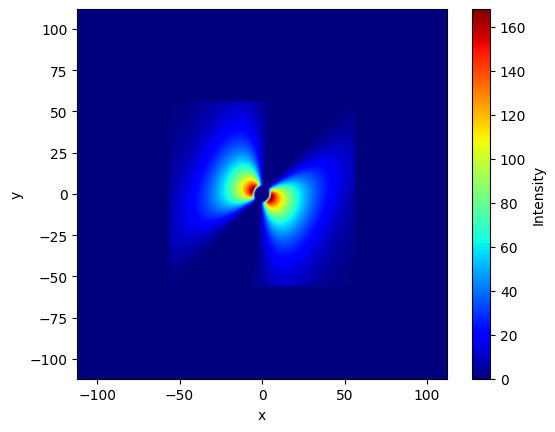

In [97]:
# Define coordinate grid
x_vals = jnp.linspace(-112, 112, 225)
# print(x_vals)
y_vals = jnp.linspace(-112, 112, 225)
x, y = jnp.meshgrid(x_vals, y_vals)

fwhm = 3.0
Norm = 100

test_wdh = gen_wdh_image(x, y, beta=0.5, h0=1.05, sigma=50, PA_deg=65, 
                         x0=0.1, fwhm=3.0, gamma=1.)

wdh_image = np.asarray(test_wdh * Norm)

plot_wdh_image(wdh_image, x_vals, y_vals, stretch="linear")